# Monte-Carlo uncertainty for the new solvers: 20 MC spectra

Monte-Carlo (MC) uncertainty estimation re-runs an unfolding solver on
`n_samples` noisy copies of the detector readings and treats the scatter of
the resulting spectra as the unfolding uncertainty. This notebook uses
**20 Monte-Carlo spectra** (`n_montecarlo=20`) with the eight solvers added
in v0.26.0 and demonstrates the **variance-reduction** techniques of
lecture 14 of the MIPT optimization course:

- **antithetic variates** - every Gaussian noise draw $\varepsilon$ is
  paired with $-\varepsilon$, halving the number of solver calls and
  cancelling the odd part of the response to noise;
- **control variates** - the linearized (delta-method) response
  $\mathrm{pinv}(A)\,\delta b$ has a *known* mean, so per-bin regression
  removes the linear part of the MC fluctuation, leaving only the genuinely
  non-linear uncertainty;
- `both` combines the two.

Every `unfold_*` call accepts `calculate_errors=True, n_montecarlo=20,
variance_reduction=...`; the 20 individual spectra are returned in
`spectrum_uncert_all` (shape `20 x n_bins`).

## 1. Detector and input data

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF

# GSF Bonner-sphere response functions
df = pd.DataFrame.from_dict(RF_GSF, orient="columns")
det = Detector(df)

# ISO Cf-252 reference spectrum and the corresponding GSF readings
# (re-used from examples/01-basic-example.ipynb)
# reference spectrum ISO Cf-252.
reference_spectrum = {
    "E_MeV": [
        1e-09,
        1.5848931924611136e-09,
        2.5118864315095803e-09,
        3.981071705534973e-09,
        6.309573444801934e-09,
        1e-08,
        1.5848931924611143e-08,
        2.511886431509581e-08,
        3.9810717055349736e-08,
        6.309573444801934e-08,
        1.0000000000000001e-07,
        1.5848931924611143e-07,
        2.5118864315095823e-07,
        3.9810717055349735e-07,
        6.309573444801937e-07,
        1.0000000000000002e-06,
        1.584893192461114e-06,
        2.5118864315095823e-06,
        3.981071705534973e-06,
        6.309573444801937e-06,
        1e-05,
        1.584893192461114e-05,
        2.5118864315095822e-05,
        3.9810717055349776e-05,
        6.309573444801943e-05,
        0.0001,
        0.00015848931924611142,
        0.0002511886431509582,
        0.0003981071705534978,
        0.0006309573444801943,
        0.001,
        0.0015848931924611143,
        0.0025118864315095825,
        0.003981071705534978,
        0.006309573444801942,
        0.01,
        0.01584893192461114,
        0.025118864315095826,
        0.039810717055349776,
        0.06309573444801943,
        0.1,
        0.15848931924611173,
        0.25118864315095824,
        0.3981071705534969,
        0.6309573444801944,
        1.0,
        1.5848931924611174,
        2.5118864315095824,
        3.9810717055349856,
        6.309573444801943,
        10.0,
        15.848931924611176,
        25.118864315095824,
        39.810717055349855,
        63.09573444801943,
        100.0,
        158.48931924611173,
        251.18864315095823,
        398.1071705534986,
        630.9573444801944,
    ],
    "Phi": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0002193244132568562,
        0.000922,
        0.0017977302145640818,
        0.0033934229230273556,
        0.00638236969883396,
        0.01212580290671056,
        0.0237,
        0.04468185467401807,
        0.0822779218679577,
        0.1450462719353082,
        0.2413649401952857,
        0.359,
        0.45221093414611185,
        0.4338707690763234,
        0.2708850368693928,
        0.0856762250762,
        0.00427,
        0.0004258199483775139,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ],
}
# effective readings of the GSF BSS for the reference spectrum [reading per second]
readings = {
    "0in": 0.00037707623092440032,
    "2in": 0.0099964357249166195,
    "3in": 0.053668754395163297,
    "5in": 0.18417232269591507,
    "6in": 0.21968230880012038,
    "8in": 0.22007281510471705,
    "10in": 0.17214800127917887,
    "12in": 0.12033147452298382,
    "15in": 0.066744761746482972,
    "18in": 0.03411946184195816,
}

print(f"energy bins: {len(reference_spectrum["E_MeV"])}, spheres: {len(readings)}")

energy bins: 60, spheres: 10


## 1. Built-in MC pipeline: 20 spectra per solver

We run every new solver with `calculate_errors=True, n_montecarlo=20` at a
3% noise level and collect the MC output. For each solver the dictionary
contains the mean/median spectrum, the per-bin standard deviation, 5-95
percentiles and the full stack of the 20 spectra in `spectrum_uncert_all`.

In [2]:
SOLVERS_MC = {
    "PGD": lambda: det.unfold_pgd(
        readings, regularization=1e-4, max_iterations=1000,
        calculate_errors=True, n_montecarlo=20, noise_level=0.03,
        random_state=42,
    ),
    "Frank-Wolfe": lambda: det.unfold_frank_wolfe(
        readings, max_iterations=1000,
        calculate_errors=True, n_montecarlo=20, noise_level=0.03,
        random_state=42,
    ),
    "Mirror descent": lambda: det.unfold_mirror_descent(
        readings, mirror_map="entropy", max_iterations=1000,
        calculate_errors=True, n_montecarlo=20, noise_level=0.03,
        random_state=42,
    ),
    "ADMM (L1+TV)": lambda: det.unfold_admm(
        readings, l1_penalty=1e-4, tv_penalty=1e-4, max_iterations=1000,
        calculate_errors=True, n_montecarlo=20, noise_level=0.03,
        random_state=42,
    ),
    "L-BFGS-B": lambda: det.unfold_lbfgsb(
        readings, regularization=1e-4, max_iterations=1000,
        calculate_errors=True, n_montecarlo=20, noise_level=0.03,
        random_state=42,
    ),
    "Coordinate descent": lambda: det.unfold_coordinate_descent(
        readings, l1_penalty=1e-4, max_iterations=1000,
        calculate_errors=True, n_montecarlo=20, noise_level=0.03,
        random_state=42,
    ),
    "Subgradient": lambda: det.unfold_subgradient(
        readings, l1_penalty=1e-4, max_iterations=1000,
        calculate_errors=True, n_montecarlo=20, noise_level=0.03,
        random_state=42,
    ),
    "Extragradient": lambda: det.unfold_extragradient(
        readings, max_iterations=1000,
        mc_noise_level=0.03,
        calculate_errors=True, n_montecarlo=20,
        random_state=42,
    ),
}

mc_results, mc_times = {}, {}
for name, run in SOLVERS_MC.items():
    t0 = time.perf_counter()
    mc_results[name] = run()
    mc_times[name] = time.perf_counter() - t0
    stack = mc_results[name]["spectrum_uncert_all"]
    print(f"{name:20s}  MC spectra: {stack.shape}  ({mc_times[name]:.1f} s)")

PGD                   MC spectra: (20, 60)  (0.2 s)


Frank-Wolfe           MC spectra: (20, 60)  (0.7 s)


Mirror descent        MC spectra: (20, 60)  (5.1 s)


ADMM (L1+TV)          MC spectra: (20, 60)  (4.3 s)
L-BFGS-B              MC spectra: (20, 60)  (0.0 s)


Coordinate descent    MC spectra: (20, 60)  (2.1 s)


Subgradient           MC spectra: (20, 60)  (0.3 s)


Extragradient         MC spectra: (20, 60)  (0.5 s)


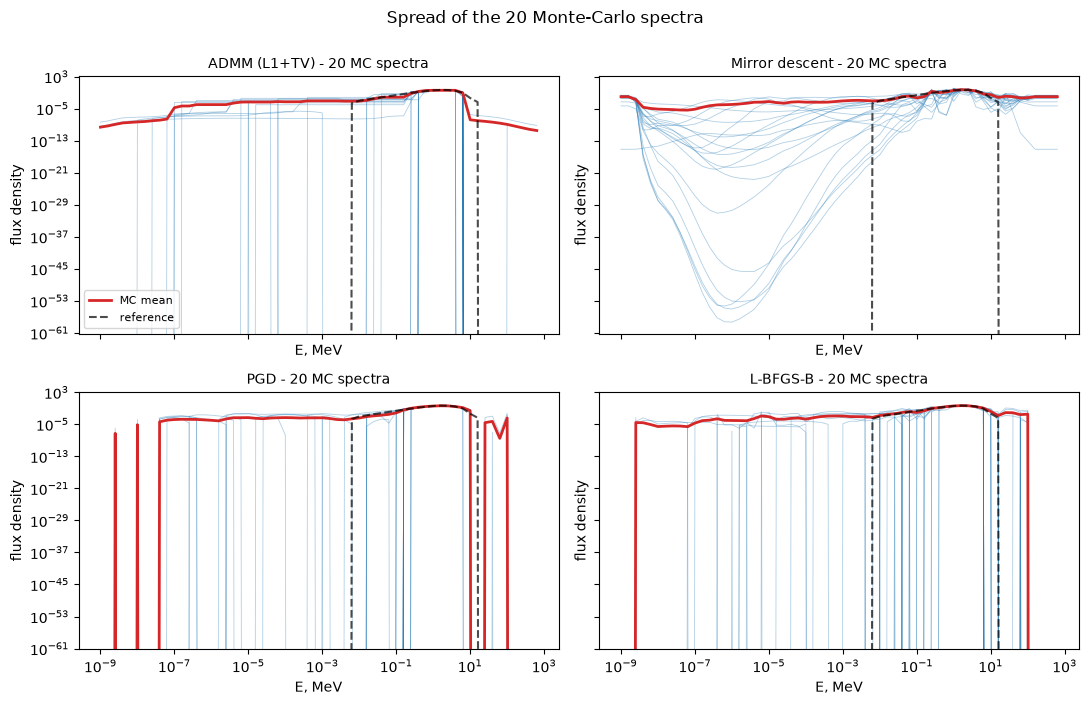

In [3]:
showcase = ["ADMM (L1+TV)", "Mirror descent", "PGD", "L-BFGS-B"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), showcase):
    res = mc_results[name]
    stack = res["spectrum_uncert_all"]
    for s in stack:
        ax.plot(res["energy"], s, color="tab:blue", lw=0.6, alpha=0.35)
    ax.plot(
        res["energy"], res["spectrum_uncert_mean"],
        color="tab:red", lw=2, label="MC mean",
    )
    ax.plot(
        reference_spectrum["E_MeV"], reference_spectrum["Phi"],
        color="black", lw=1.5, ls="--", alpha=0.7, label="reference",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{name} - 20 MC spectra", fontsize=10)
    ax.set_xlabel("E, MeV")
    ax.set_ylabel("flux density")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Spread of the 20 Monte-Carlo spectra", y=1.0)
fig.tight_layout()
plt.show()

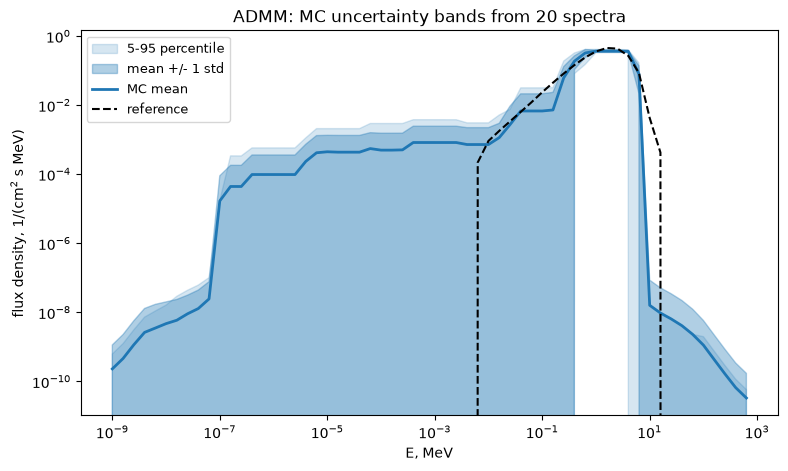

In [4]:
res = mc_results["ADMM (L1+TV)"]
energy = res["energy"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(
    energy,
    res["spectrum_uncert_percentile_5"],
    res["spectrum_uncert_percentile_95"],
    color="tab:blue", alpha=0.18, label="5-95 percentile",
)
ax.fill_between(
    energy,
    res["spectrum_uncert_mean"] - res["spectrum_uncert_std"],
    res["spectrum_uncert_mean"] + res["spectrum_uncert_std"],
    color="tab:blue", alpha=0.35, label="mean +/- 1 std",
)
ax.plot(energy, res["spectrum_uncert_mean"], color="tab:blue", lw=2, label="MC mean")
ax.plot(
    reference_spectrum["E_MeV"], reference_spectrum["Phi"],
    color="black", lw=1.5, ls="--", label="reference",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("E, MeV")
ax.set_ylabel("flux density, 1/(cm$^2$ s MeV)")
ax.set_title("ADMM: MC uncertainty bands from 20 spectra")
ax.legend(fontsize=9)
plt.show()

Mean relative MC uncertainty across the spectrum for each solver:

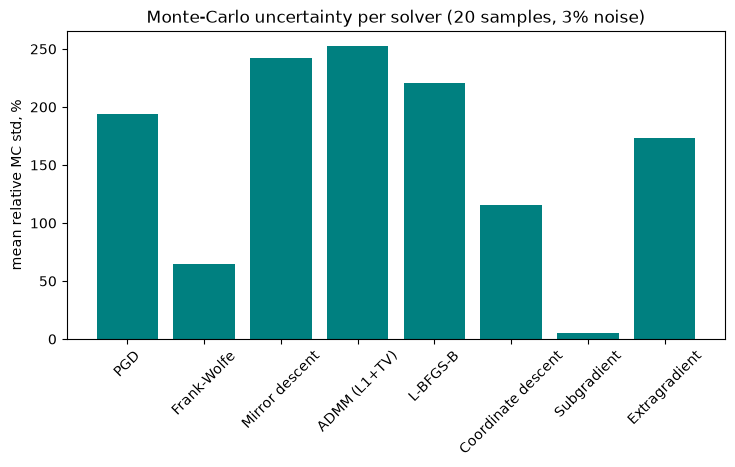

,PGD,Frank-Wolfe,Mirror descent,ADMM (L1+TV),L-BFGS-B,Coordinate descent,Subgradient,Extragradient
"mean rel std, %",1.94,0.65,2.42,2.53,2.21,1.16,0.06,1.73


In [5]:
rel_std = {
    name: float(
        np.mean(
            res["spectrum_uncert_std"]
            / np.maximum(res["spectrum_uncert_mean"], 1e-30)
        )
    )
    for name, res in mc_results.items()
}
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(rel_std.keys(), [100 * v for v in rel_std.values()], color="teal")
ax.set_ylabel("mean relative MC std, %")
ax.set_title("Monte-Carlo uncertainty per solver (20 samples, 3% noise)")
ax.tick_params(axis="x", rotation=45)
plt.show()
display(
    pd.DataFrame.from_dict(rel_std, orient="index", columns=["mean rel std, %"])
    .T.style.format("{:.2f}")
)

## 2. Variance reduction (lecture 14)

With only 20 samples the raw MC standard deviation is noisy. Variance
reduction makes small-sample estimates usable:

- `antithetic` - noise pairs $1 \pm \varepsilon$;
- `control` - regression on the linearized response with known mean;
- `both` - antithetic + control.

The estimated efficiency is reported per bin as
`variance_reduction_factor` (mean ratio of raw to corrected variance).

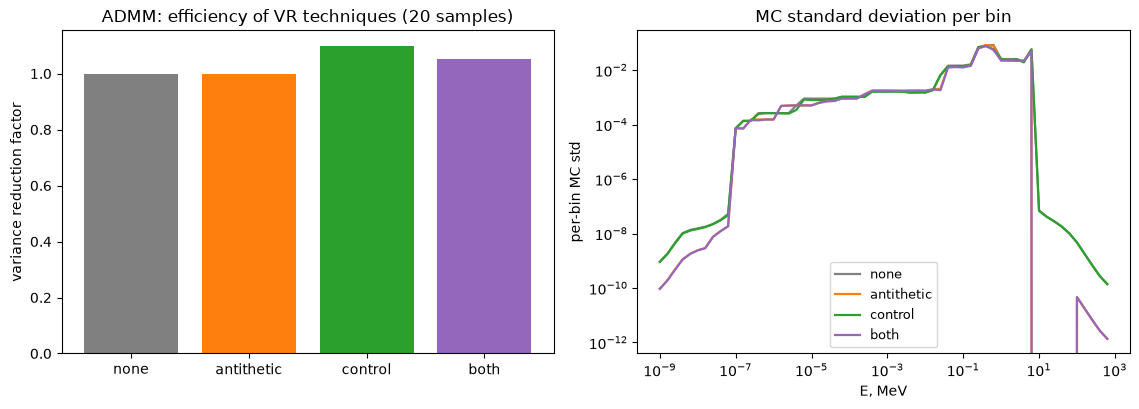

,VR factor
mode,
none,1.00x
antithetic,1.00x
control,1.10x
both,1.05x


In [6]:
vr_modes = ["none", "antithetic", "control", "both"]
vr_results = {}
for mode in vr_modes:
    vr_results[mode] = det.unfold_admm(
        readings, l1_penalty=1e-4, tv_penalty=1e-4, max_iterations=1000,
        calculate_errors=True, n_montecarlo=20, noise_level=0.03,
        random_state=42, variance_reduction=mode,
    )

factors = [vr_results[m].get("variance_reduction_factor") or 1.0 for m in vr_modes]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].bar(vr_modes, factors, color=["gray", "tab:orange", "tab:green", "tab:purple"])
axes[0].set_ylabel("variance reduction factor")
axes[0].set_title("ADMM: efficiency of VR techniques (20 samples)")
for mode, color in zip(vr_modes, ["gray", "tab:orange", "tab:green", "tab:purple"]):
    res = vr_results[mode]
    axes[1].plot(
        res["energy"], res["spectrum_uncert_std"],
        color=color, lw=1.6, label=mode,
    )
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("E, MeV")
axes[1].set_ylabel("per-bin MC std")
axes[1].set_title("MC standard deviation per bin")
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "mode": vr_modes,
            "VR factor": [f"{f:.2f}x" for f in factors],
        }
    ).set_index("mode")
)

## 3. Manual Monte-Carlo: doserate distribution over 20 samples

The built-in pipeline returns spectral statistics; sometimes the quantity
of interest is a *scalar* such as the ambient dose rate. Here we generate 20
noisy readings realizations manually, unfold each of them with ADMM and PGD
and look at the distribution of the rotational dose rate - the same recipe
one would use for any scalar response function.

,count,mean,std,min,25%,50%,75%,max
ADMM,20.0,209.9,3.0,203.1,208.7,210.6,211.8,213.8
PGD,20.0,213.7,3.0,207.0,212.7,214.5,215.8,217.9


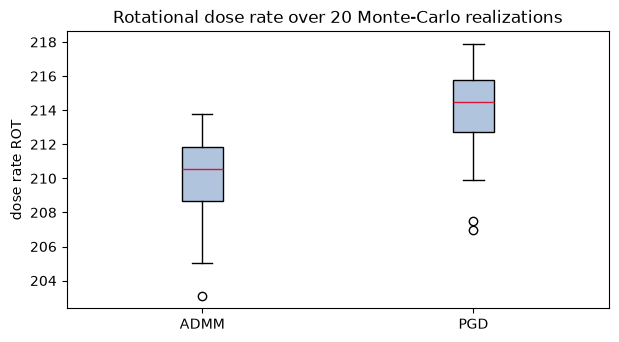

In [7]:
rng = np.random.default_rng(7)
dose_samples = {"ADMM": [], "PGD": []}
for _ in range(20):
    noisy = {k: float(v * (1 + rng.normal(0, 0.03))) for k, v in readings.items()}
    r_admm = det.unfold_admm(noisy, l1_penalty=1e-4, tv_penalty=1e-4, max_iterations=1000)
    r_pgd = det.unfold_pgd(noisy, regularization=1e-4, max_iterations=1000)
    dose_samples["ADMM"].append(r_admm["doserates"]["ROT"])
    dose_samples["PGD"].append(r_pgd["doserates"]["ROT"])

doses = pd.DataFrame(dose_samples)
display(doses.describe().T.style.format("{:.1f}"))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.boxplot(
    [doses["ADMM"], doses["PGD"]],
    tick_labels=["ADMM", "PGD"],
    patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue"),
    medianprops=dict(color="crimson"),
)
ax.set_ylabel("dose rate ROT")
ax.set_title("Rotational dose rate over 20 Monte-Carlo realizations")
plt.show()

## Summary

- Every new solver plugs into the standard MC pipeline: 20 spectra per
  solver are produced with a single `calculate_errors=True,
  n_montecarlo=20` call and returned in `spectrum_uncert_all`.
- Variance reduction (`antithetic`, `control`, `both`) reduces the MC
  variance of small samples by removing the linearized (delta-method) part
  of the fluctuation and pairing antithetic noise draws, exactly as in
  lecture 14 of the MIPT course.
- For scalar quantities (dose rates) a small manual MC loop over noisy
  readings reproduces the same machinery and gives the full distribution,
  not only mean and std.

See `52-optimization-course-methods.ipynb` for the solvers themselves,
duality-gap certificates and 1-D regularization selection, and
`54-noise-robustness.ipynb` for the noise-robustness study.